# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("customer_booking.csv")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [19]:
df.shape

(50000, 14)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [10]:
df["flight_day"].unique()

<StringArray>
['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri']
Length: 7, dtype: str

In [11]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [12]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [13]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.


In [16]:
print("Unique values in each column")
for column in df.columns.to_list():
    print("")
    print(f"{column} : {df[column].nunique()}")


Unique values in each column

num_passengers : 9

sales_channel : 2

trip_type : 3

purchase_lead : 470

length_of_stay : 335

flight_hour : 24

flight_day : 7

route : 799

booking_origin : 104

wants_extra_baggage : 2

wants_preferred_seat : 2

wants_in_flight_meals : 2

flight_duration : 21

booking_complete : 2


## Data Visualization

This section explores the main patterns in the dataset through visualizations.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

### Target Column Distribution

Class 0 represents customers who did not complete a booking, while class 1 represents customers who completed a booking.

Text(0.5, 1.0, 'Target Column Distribution')

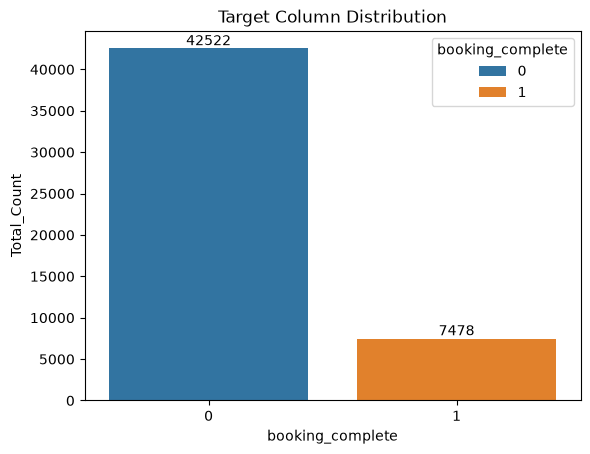

In [17]:
ax = sns.countplot(data=df, x="booking_complete", hue="booking_complete")
for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("booking_complete")
plt.ylabel("Total_Count")
plt.title("Target Column Distribution")

The target variable is imbalanced, with approximately 85% of observations belonging to `class 0` and 15% to `class 1`. Although `class 1` contains 7,478 observations, which may provide enough examples for the model to learn useful patterns, the effect of this imbalance cannot be determined until the model is trained and evaluated using suitable classification metrics.

### Numerical Features and Relationship with Target

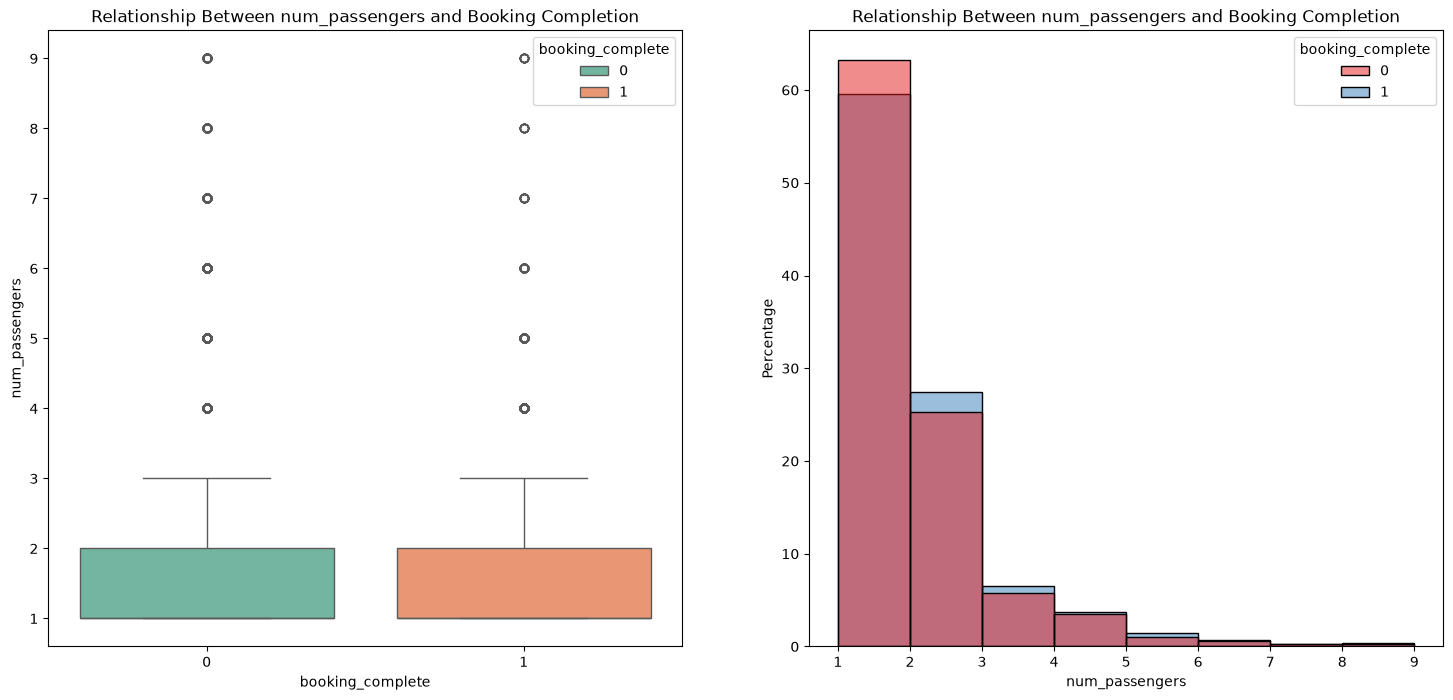

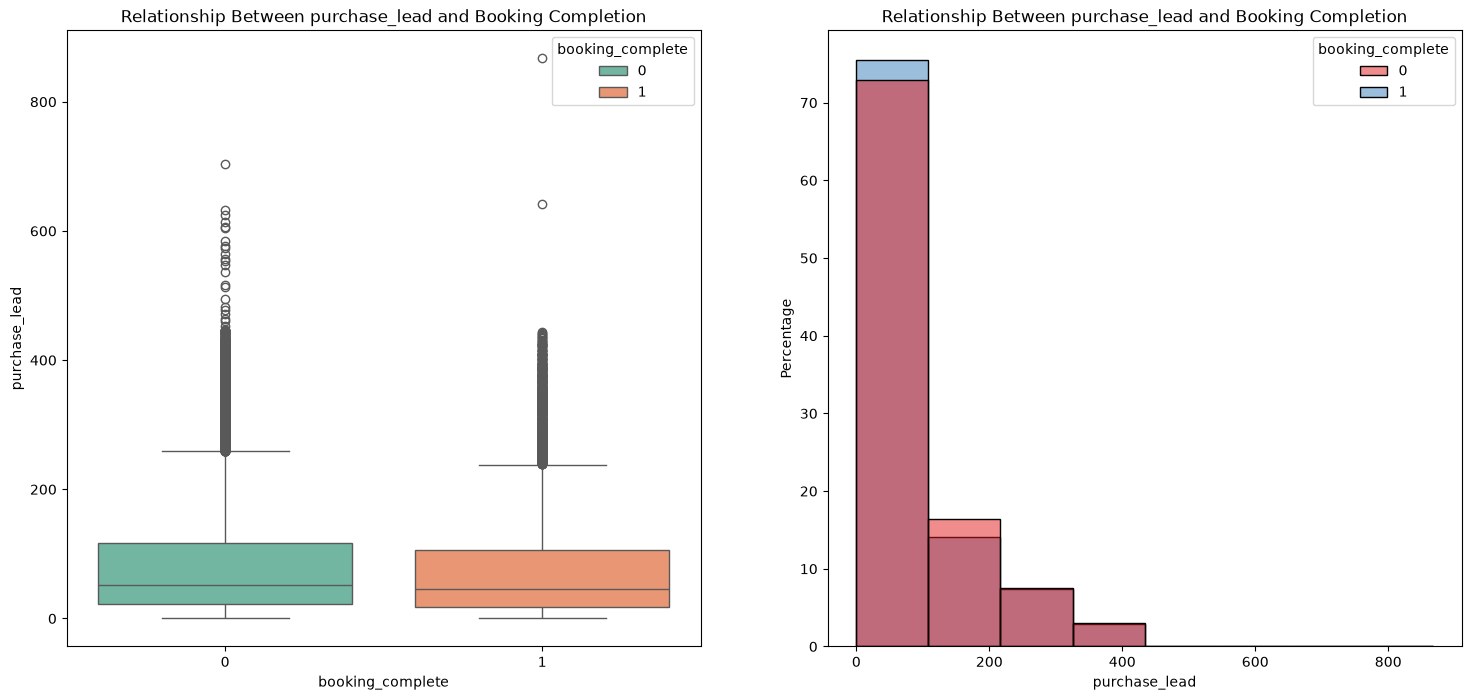

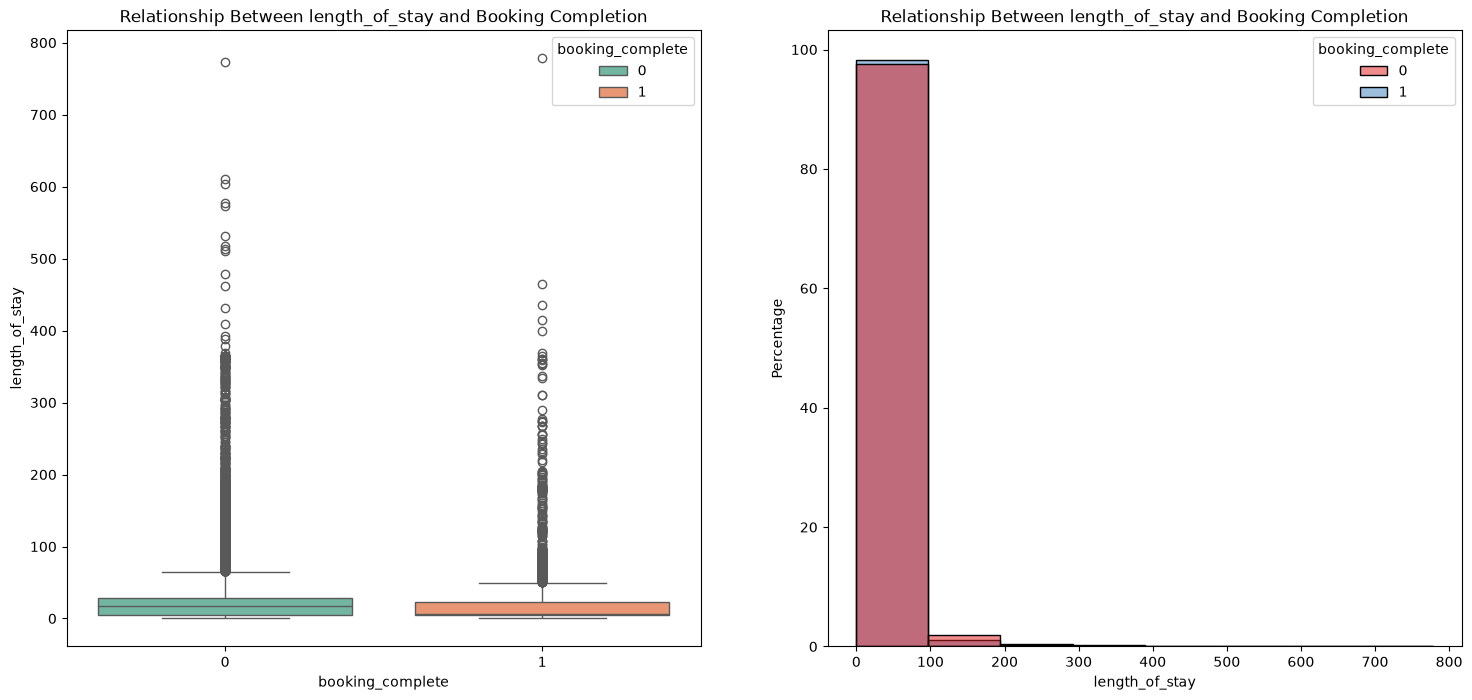

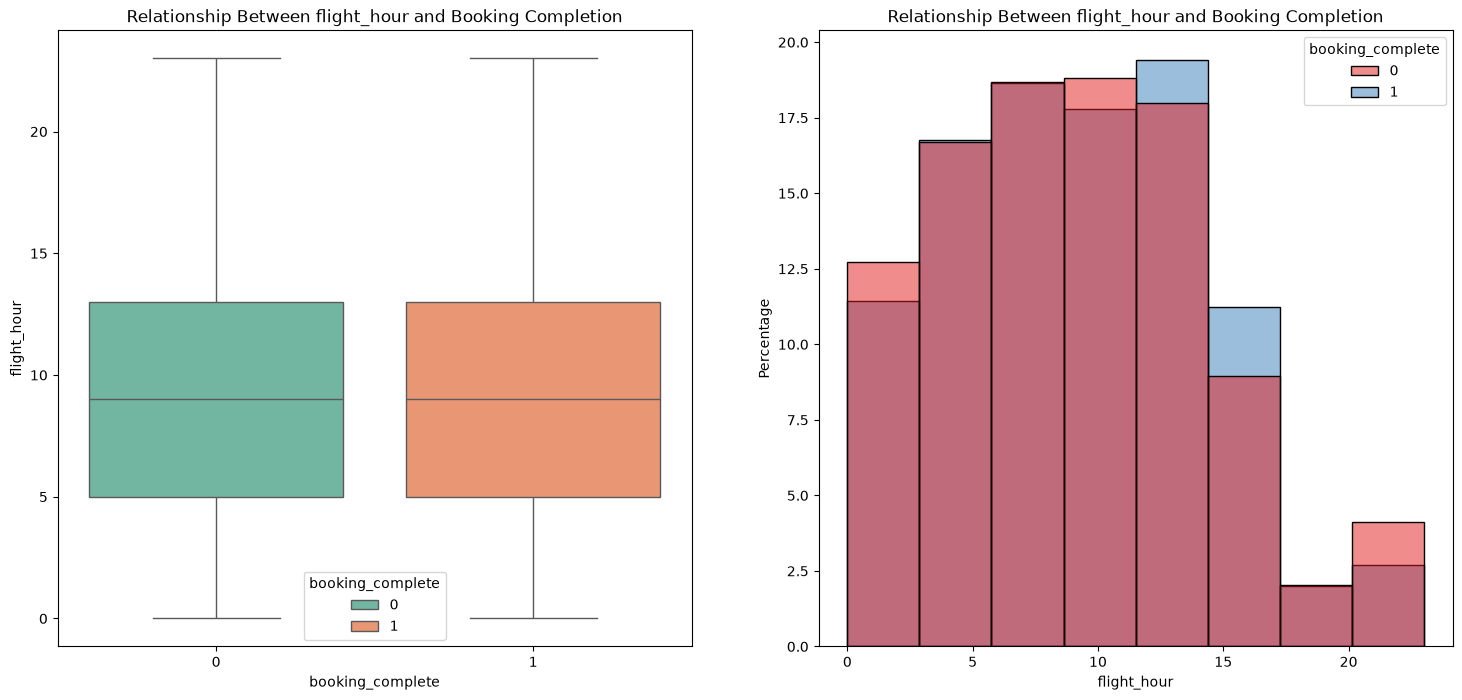

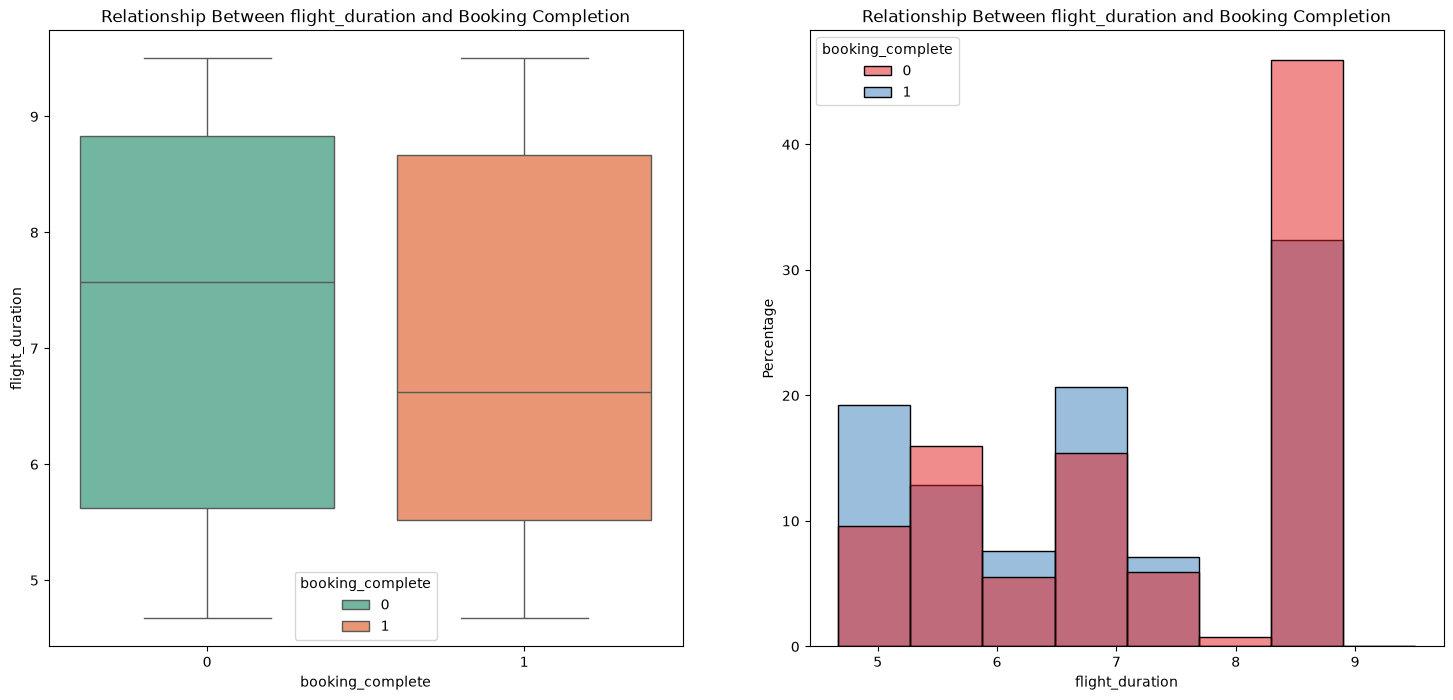

In [21]:
numerical_columns = df[['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']]

for column in numerical_columns:
    fig = plt.figure(figsize=(18,8))
    ax0 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,2)

    sns.boxplot(data=df, x="booking_complete", y=column, hue="booking_complete", palette="Set2" ,ax=ax0)
    ax0.set_title(f"Relationship Between {column} and Booking Completion")
    ax0.set_xlabel("booking_complete")
    ax0.set_ylabel(column)

    sns.histplot(data=df, x=column, hue="booking_complete", stat="percent", common_norm=False ,bins=8 ,palette="Set1", ax=ax1)
    ax1.set_title(f"Relationship Between {column} and Booking Completion")
    ax1.set_xlabel(column)
    ax1.set_ylabel('Percentage')

    plt.show()



The initial visualization for `length_of_stay` is heavily compressed by extreme values, making the relationship with booking completion difficult to interpret. A more focused visualization will be used to examine the main distribution in greater detail.

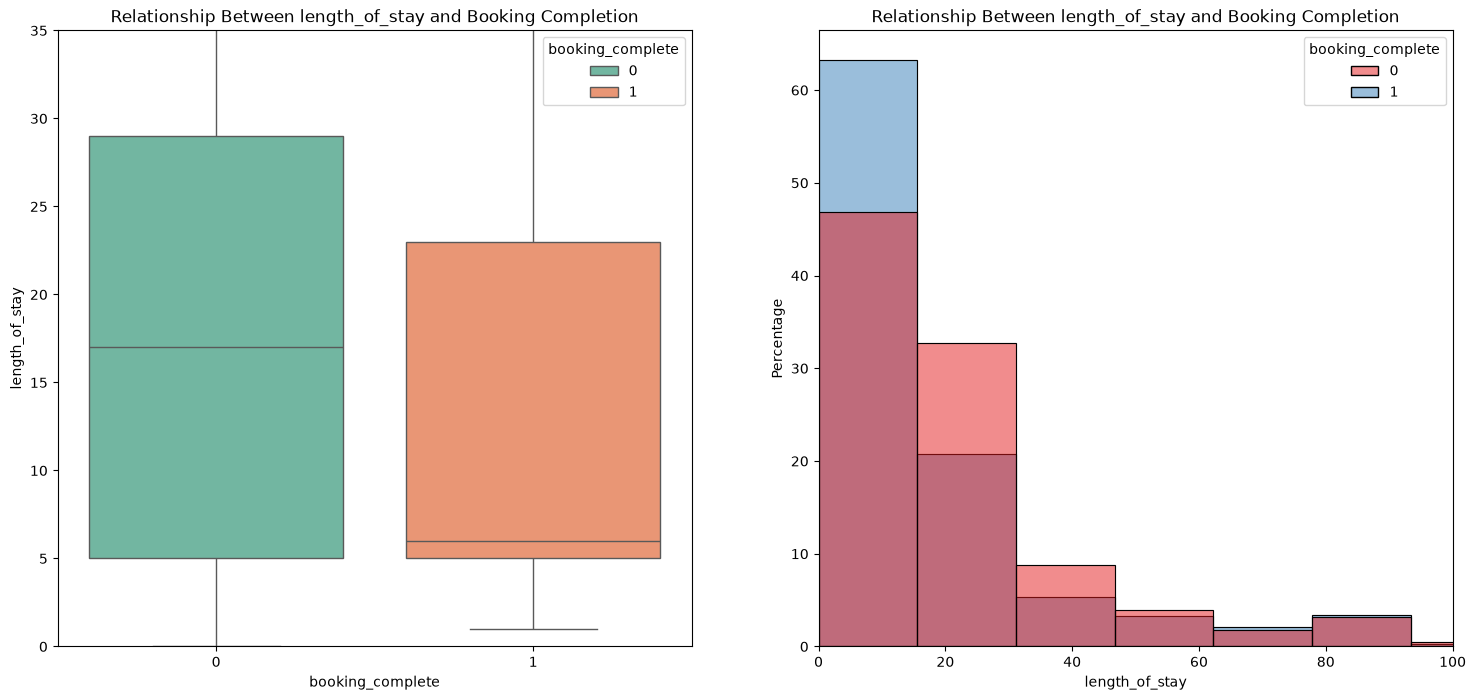

In [38]:
fig = plt.figure(figsize=(18,8))
ax0 = fig.add_subplot(1,2,1)
ax1 = fig.add_subplot(1,2,2)

sns.boxplot(data=df, x="booking_complete", y="length_of_stay", hue="booking_complete", palette="Set2" ,ax=ax0)
ax0.set_title(f"Relationship Between length_of_stay and Booking Completion")
ax0.set_xlabel("booking_complete")
ax0.set_ylabel('length_of_stay')
ax0.set_ylim(0,35)

sns.histplot(data=df, x='length_of_stay', hue="booking_complete", stat="percent", common_norm=False, bins=50 ,palette="Set1", ax=ax1)
ax1.set_title(f"Relationship Between length_of_stay and Booking Completion")
ax1.set_xlabel('length_of_stay')
ax1.set_ylabel('Percentage')
ax1.set_xlim(0,100)

plt.show()

After zooming into both the histogram and boxplot, a clearer relationship between `length_of_stay` and booking completion was observed. Customers who completed their bookings generally had shorter stays, with a noticeably lower median and greater concentration in the lower stay-duration range. This suggests that `length_of_stay` may be a useful predictive feature.